In [ ]:
from google.colab import files
uploaded = files.upload()



Saving Sleep_health_and_lifestyle_dataset.xlsx to Sleep_health_and_lifestyle_dataset.xlsx


In [ ]:
import pandas as pd

df = pd.read_excel('Sleep_health_and_lifestyle_dataset.xlsx')
print(df.head())


   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8        Obese   
4                 4                       30             8        Obese   

  Blood Pressure  Heart Rate  Daily Steps Sleep Disorder  
0         126/83          77         4200            NaN  
1         125/80          75      

In [ ]:
df.isnull().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0


In [ ]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
# Calculate average sleep duration by occupation
avg_sleep_by_occupation = df.groupby('Occupation')['Sleep Duration'].mean().reset_index()


avg_sleep_by_occupation.columns = ['Occupation', 'Average Sleep Duration']

# Display the result
print(avg_sleep_by_occupation)


              Occupation  Average Sleep Duration
0             Accountant                7.113514
1                 Doctor                6.970423
2               Engineer                7.987302
3                 Lawyer                7.410638
4                Manager                6.900000
5                  Nurse                7.063014
6   Sales Representative                5.900000
7            Salesperson                6.403125
8              Scientist                6.000000
9      Software Engineer                6.750000
10               Teacher                6.690000


In [ ]:
df['Stress Index'] = df['Stress Level'] * df['Sleep Duration']
df['Sleep Efficiency'] = df['Sleep Duration'] / 8  # Assuming 8 hours is optimal


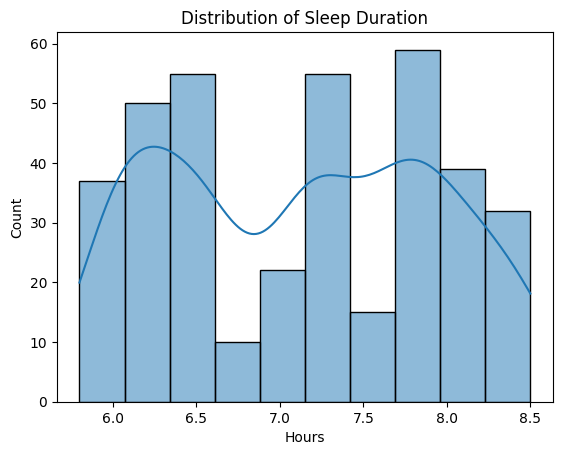

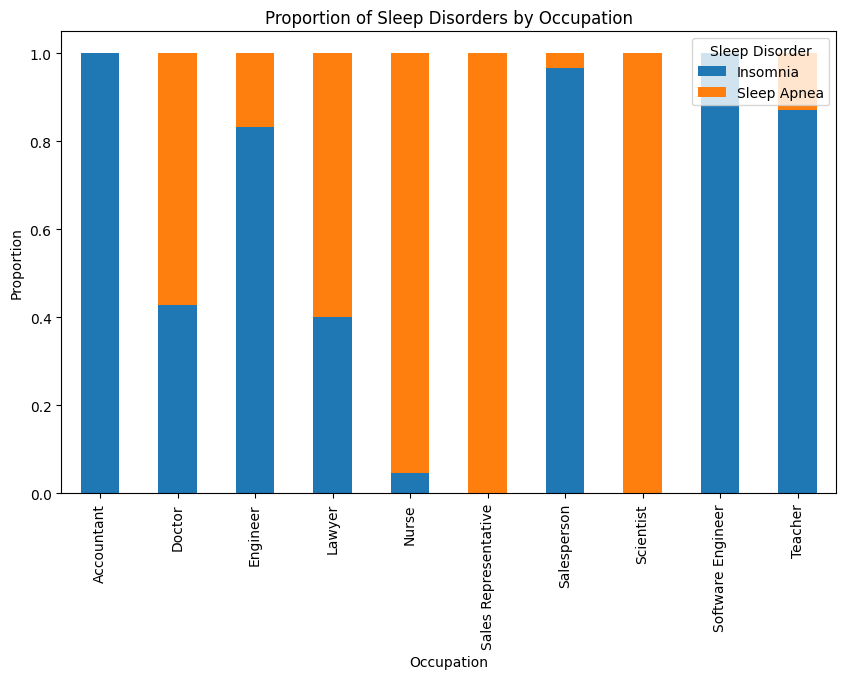

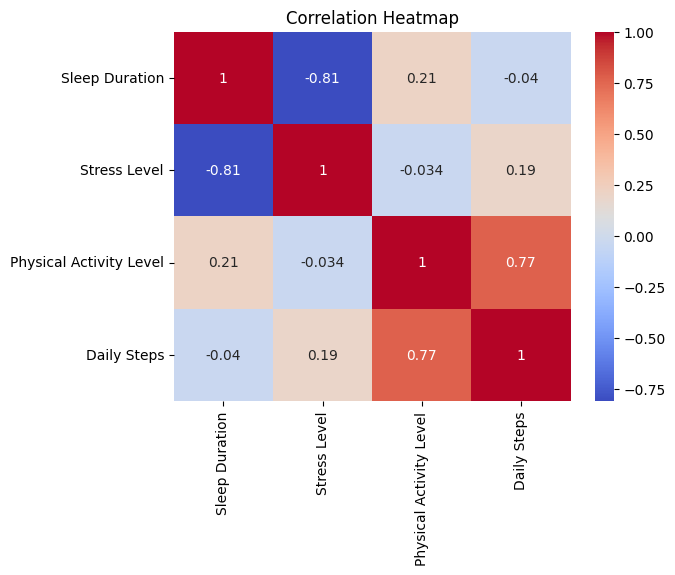

In [ ]:
sns.histplot(df['Sleep Duration'], kde=True)
plt.title('Distribution of Sleep Duration')
plt.xlabel('Hours')
plt.show()

# Sleep Disorders by Occupation
occupation_disorders = df.groupby('Occupation')['Sleep Disorder'].value_counts(normalize=True).unstack()
occupation_disorders.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Proportion of Sleep Disorders by Occupation')
plt.ylabel('Proportion')
plt.show()

# Correlation Heatmap
correlation_matrix = df[['Sleep Duration', 'Stress Level', 'Physical Activity Level', 'Daily Steps']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(df['BMI Category'], df['Sleep Disorder'])

# Display the contingency table
print("Contingency Table:")
print(contingency_table)

# Perform the Chi-Square test
chi2_result = chi2_contingency(contingency_table)

# Extract the p-value from the test result
p_value = chi2_result[1]


Contingency Table:
Sleep Disorder  Insomnia  Sleep Apnea
BMI Category                         
Normal                 7            5
Normal Weight          2            2
Obese                  4            6
Overweight            64           65


In [ ]:
from scipy.stats import f_oneway, chi2_contingency

# ANOVA: Sleep Duration across Occupations
grouped = [df[df['Occupation'] == occ]['Sleep Duration'] for occ in df['Occupation'].unique()]
anova_result = f_oneway(*grouped)
print(f"ANOVA p-value: {anova_result.pvalue}")

# Chi-Square Test: Sleep Disorders by BMI Category
contingency_table = pd.crosstab(df['BMI Category'], df['Sleep Disorder'])
chi2_result = chi2_contingency(contingency_table)
print(f"Chi-Square p-value: {chi2_result[1]}")


ANOVA p-value: 2.9117522724389375e-30
Chi-Square p-value: 0.8650218472482435


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Prepare data for modeling
X = df[['Stress Level', 'Physical Activity Level', 'Sleep Duration', 'Daily Steps']]
y = df['Sleep Disorder'].apply(lambda x: 1 if x != 'None' else 0)  # Binary encoding: 1 for disorder, 0 for none

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Model Evaluation
y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))




              precision    recall  f1-score   support

           1       1.00      1.00      1.00        75

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75



In [ ]:
df.to_csv('Processed_Sleep_Health_Data.csv', index=False)
from google.colab import files
files.download('Processed_Sleep_Health_Data.csv')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>